Lugo Avalos Vanessa Aidee 6AM1

# Librerías
Se importan las librerías necesarias, numpy y pandas para la manipulación de datos, matplotlib y seaborn para visualización, y sklearn para escalar, entrenar el modelo K-means y reducir dimensionalidad con PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Carga del conjunto de datos

In [2]:
df = pd.read_csv("Mall_Customers.csv")

# Visualización del conjunto de datos
Se visualizan los primeros 5 registros del conjunto de datos, donde se tiene las variables de ID, genero, edad, ingreso anual del cliente, y la puntuación de gasto en un rango del 1 al 100.

In [3]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


# Preprocesamiento
Se realiza el preprocesamiento del conjunto de datos, donde se elimina la columna de ID, y mediante la función map se le asigna a la serie de genero el 0 en caso de ser masculino y el 1 en caso de ser femenino.

In [4]:
df.drop("CustomerID", axis = 1, inplace = True)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   19                  15                      39
1       0   21                  15                      81
2       1   20                  16                       6
3       1   23                  16                      77
4       1   31                  17                      40


# Histogramas
Se grafican las distribuciones de los datos de cada columna, es decir, la distribución de la edad, ingreso anual y la puntuación del gaasto. Esto se realiza utilizando la función de hist() de matplotlib. Se observa que las distribuciones no son normales, pues la edad tiene un ligero sesgo hacia la izquierda, mientras que el ingreso anual tiene este sesgo más visible, y la distribución de la puntuación del gasto tiene picos.

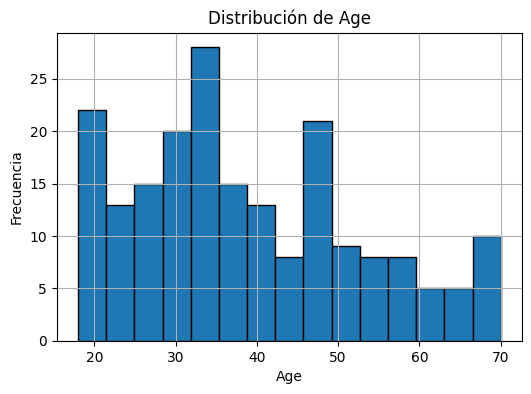

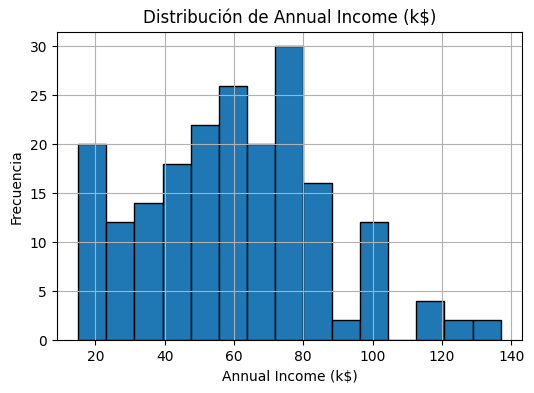

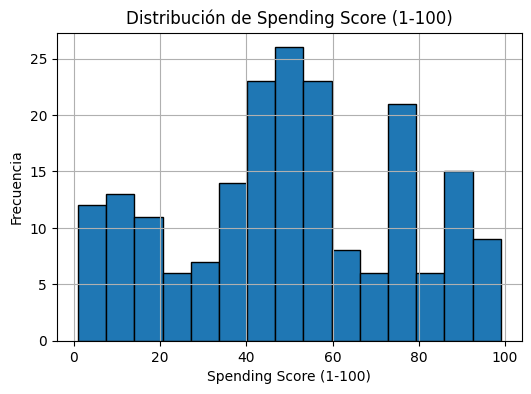

In [5]:
columnas = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
for col in columnas:
    plt.figure(figsize = (6, 4))
    plt.hist(df[col], bins = 15, edgecolor = 'black')
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.show()

# Escalar datos para el algoritmo k-means
Para poder realizara el entrenamiento de k-means se require establecer las variables para X, que en este casso son edad, ingreso anual y la puntuaión del gasto, de manera que se escalan estos datos.

In [6]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Número óptimo de clusters con el método del codo
El método codo tiene como objetivo hacer grupos es que los elementos dentro de un grupo se parezcan mucho entre sí (que el grupo sea compacto). Cada vez que K-Means termina de agrupar, calcula un valor matemático llamado inercia (o WCSS, Suma de Cuadrados Dentro del Clúster). En la gráfica se observa que si k = 1 entocnes la inercia es alta, y a medida que k aumenta va disminuyendo esta inercia.

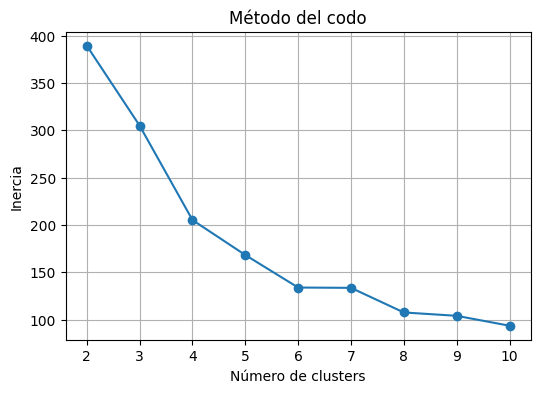

In [7]:
inercia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 7)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize = (6, 4))
plt.plot(range(2, 11), inercia, marker = 'o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

# K-means
El modelo de K-means  (k-medias) es un algoritmo de aprendizaje no supervisado donde se divide el conjunto den k grupos o clusters, donde los elementos dentro de cada cluster son muy similares entre sí y muy diferentes entre sí.  

In [8]:
optimal_k = 5
kmeans = KMeans(n_clusters = optimal_k, random_state = 7)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Centroides
El centroide, o centro del clúster, es la media o la mediana de todos los puntos dentro del clúster, según las características de los datos.

In [9]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Visualización de clusters y centroides
Se realiza la gráfica de los puntos de los centroides marcados con x y el agrupamiento de los clusters, es decir, los clientes que se encuentran alrededor de cada centroide, de manera que estos son similares entre sí.

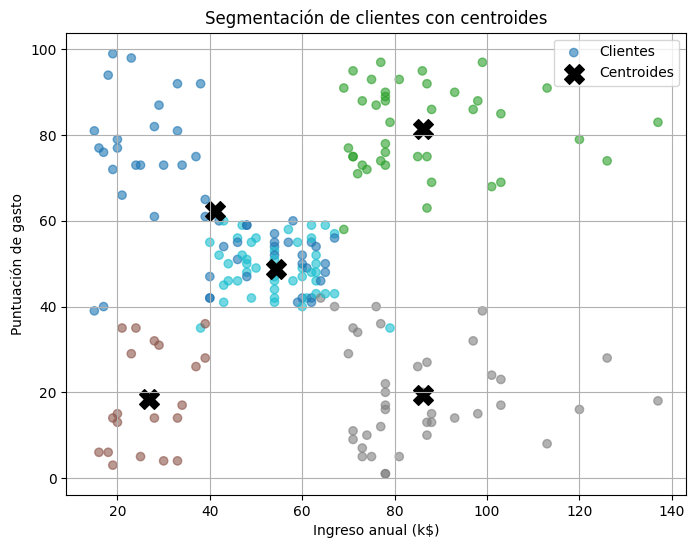

In [10]:
plt.figure(figsize = (8, 6))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            c = df["Cluster"], cmap = "tab10", alpha = 0.6, label = "Clientes")
plt.scatter(centroids_original[:, 1], centroids_original[:, 2], s = 200,
            c = 'black', marker = 'X', label = 'Centroides')
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Puntuación de gasto")
plt.title("Segmentación de clientes con centroides")
plt.legend()
plt.grid(True)
plt.show()

# Perfil promedio de cada clúster
Se visualiza el promedio de los datos de los clientes correspondientes a cada cluster, se observa que el cluster 0 le corresponde 25 años, con ingreso de 41.09 y puntuación de gasto de 62%. En total, se tienen 5 clusters donde la edad promedio máxima es de 55 para el cluster 4.

In [11]:
print("\nPerfil promedio de cada cluster:")
perfil_promedio = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()
print(perfil_promedio)


Perfil promedio de cada cluster:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        25.185185           41.092593               62.240741
1        32.875000           86.100000               81.525000
2        46.250000           26.750000               18.350000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


# Visualización del perfil promedio de cada clúster
Se realiza la gráfica para visualizar los datos promedio de cada cluster de clientes, donde se observa que dependiendo del cluster las caracteristicas son similares, y que fuera del cluster las caracteristas son diferentes.

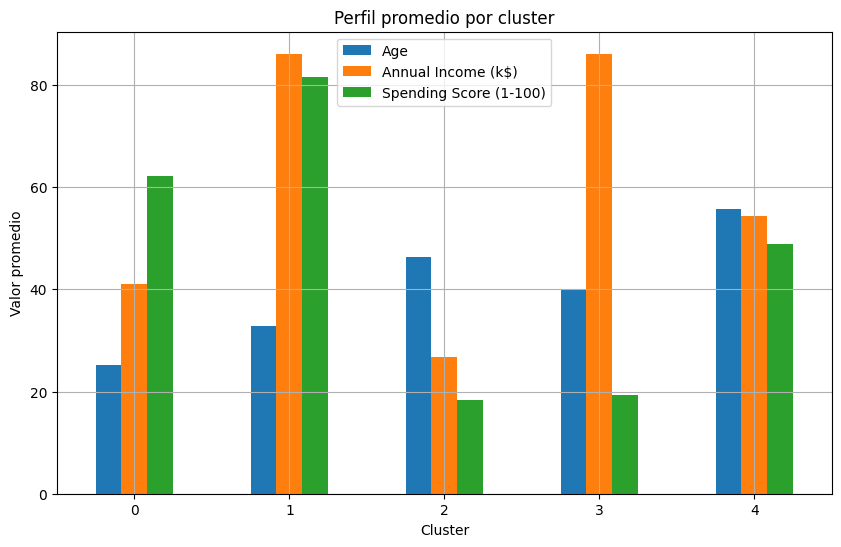

In [12]:
perfil_promedio.plot(kind = "bar", figsize = (10, 6))
plt.title("Perfil promedio por cluster")
plt.ylabel("Valor promedio")
plt.xticks(rotation = 0)
plt.grid(True)
plt.show()

# Distribución por género en cada clúster
Se realiza el calculo de la distribución del genero para cada clúster, donde se observa que la mayoria de clusters tienen una cantidad similar de hombres y mujeres, donde siempre predomina la cantidad de mujeres, sin embargo, para el cluster 2 se tiene poca cantidad de personas comparado con los demás.

In [13]:
print("\nDistribución por género en cada cluster (0 = Hombre, 1 = Mujer):")
genero_cluster = df.groupby("Cluster")["Gender"].value_counts().unstack()
print(genero_cluster)


Distribución por género en cada cluster (0 = Hombre, 1 = Mujer):
Gender    0   1
Cluster        
0        22  32
1        18  22
2         8  12
3        20  19
4        20  27


# Visualización por género en cada clúster
Se realiza la gráfica para poder visualizar de manera sencilla la distribución de genero de cada cluster, donde se confirma que en la mayoría de los casos predomina la cantidad de mujeres, excepto en el cluster 3, donde predominan ligeramente los hombres. Además, se confirma que el cluster 2 tiene menor cantidad de clientes.

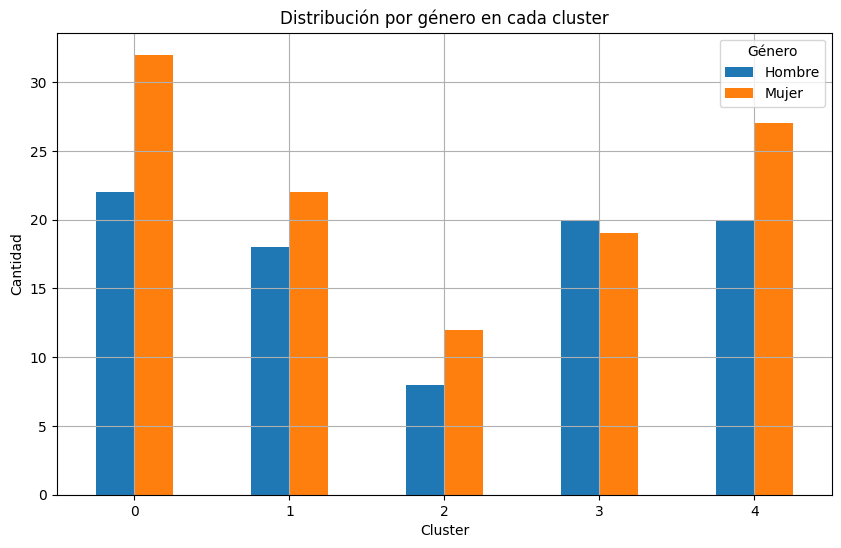

In [14]:
genero_cluster.plot(kind = 'bar', stacked = False, figsize = (10, 6))
plt.title("Distribución por género en cada cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.xticks(rotation = 0)
plt.legend(title = "Género", labels = ["Hombre", "Mujer"])
plt.grid(True)
plt.show()

# Conclusión
Para conlcuir, el algoritmo de K-means permite la separación del conjunto de datos mediante el agrupamiento de los datos de acuerdo con sus características y el canculo de los centroides, de manera que los datos dentro de cada clúster son similares entre sí y diferentes a los datos de los demás clústers. Para este conjunto de datos, se separaron los clientes de acuerdo con la edad, el ingreso anual y la puntuación de datos, además se visualizó la distribución de cada uno y el genero.